# Source localization 

The aim of this lecture is to teach you how to compute and apply
a linear inverse method such as MNE/dSPM/sLORETA on evoked/raw/epochs data.

`
Authors: Marijn van Vliet, Britta Westner, Alexandre Gramfort, Denis Engemann 
`

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

import mne

# Change the following path to where the folder ds000117 is on your disk.
data_path = "./ds000117_pruned"  # `./` means the folder of this notebook

# Change the following path to where you unzipped the extra data (`extra_meg_data.zip`) on your disk.
extra_path = "./extra_data_mne"  # `./` means the folder of this notebook

## Read epochs and compute ERP/ERF

In [25]:
epochs_fname = f"{data_path}/derivatives/meg_derivatives/sub-01/ses-meg/meg/sub-01_ses-meg_task-facerecognition_run-01_proc-sss-epo.fif"
epochs = mne.read_epochs(epochs_fname)
epochs.info

Reading /home/vanvlm1/projects/mne_practical_meeg_2025/ds000117_pruned/derivatives/meg_derivatives/sub-01/ses-meg/meg/sub-01_ses-meg_task-facerecognition_run-01_proc-sss-epo.fif ...
    Found the data of interest:
        t =    -466.67 ...    2033.33 ms
        0 CTF compensation matrices available
Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated


<Info | 24 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: []
 ch_names: MEG0113, MEG0112, MEG0111, MEG0122, MEG0123, MEG0121, MEG0132, ...
 chs: 204 Gradiometers, 102 Magnetometers, 70 EEG, 2 EOG
 custom_ref_applied: True
 description: (meg) Vectorview system at Cambridge
 dev_head_t: MEG device -> head transform
 dig: 137 items (3 Cardinal, 5 HPI, 75 EEG, 54 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 2 items (dict)
 line_freq: 50.0
 lowpass: 40.0 Hz
 meas_date: 1941-03-22 11:04:14 UTC
 meas_id: 4 items (dict)
 nchan: 378
 proc_history: 1 item (list)
 proj_id: 47
 proj_name: dgw_studies
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | id: 813, birthday: 1978-01-01>
>

In [26]:
# since we computed our forward model for MEG only, we drop the EEG channels
epochs.pick_types(meg=True, eeg=False)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<EpochsFIF | 79 events (all good), -0.467 – 2.033 s (baseline -0.2 – 0 s), ~145.4 MiB, data loaded,
 'face/famous/first': 13
 'face/famous/immediate': 3
 'face/famous/long': 6
 'face/unfamiliar/first': 17
 'face/unfamiliar/immediate': 4
 'face/unfamiliar/long': 6
 'scrambled/first': 15
 'scrambled/immediate': 9
 'scrambled/long': 6>

Let's compute the evoked responses for two conditions: _faces_  and  _scrambled_

In [27]:
evoked_face = epochs["face"].average()
evoked_scrambled = epochs["scrambled"].average()

Compute the contrast between the two conditions:

Fitted sphere radius:         86.5 mm
Origin head coordinates:      4.2 6.0 42.4 mm
Origin device coordinates:    1.7 14.7 -5.5 mm


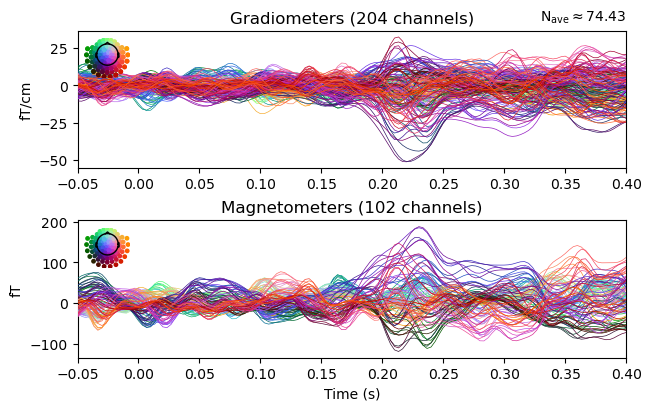

In [28]:
evoked_contrast = mne.combine_evoked([evoked_face, evoked_scrambled], [0.5, -0.5])
evoked_contrast.crop(-0.05, 0.4)

# Fit a sphere to the headshape in order to make proper topo plots.
# This is needed for this particular dataset and may not be necessary for yours.
radius, center, _ = mne.bem.fit_sphere_to_headshape(epochs.info, dig_kinds="eeg")
sphere = tuple(center) + (radius,)

# Plot the contrast.
evoked_contrast.plot(sphere=sphere);

## Prepare for MNE source estimation

In order to perform MNE source estimation, we first need to estimate the covariance between the sensors.
This is typically done on a stretch of data without experimental effects, containing only "noise", hence we refer to this covariance matrix as the "noise covariance".
In many cases, we can use the baseline period for this.

In [68]:
noise_cov = mne.compute_covariance(epochs, tmin=-.25, tmax=0.,  # use the baseline
                                   rank="info")

    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 306 -> 68
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 6004
[done]


Let's visualize our covariance matrices. We can see that they are severly rank deficient. Can you guess why?

Let's keep a mental note that we may have to take this into account later!

Computing rank from covariance with rank=None
    Using tolerance 1.8e-14 (2.2e-16 eps * 102 dim * 0.79  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.4e-13 (2.2e-16 eps * 204 dim * 3.1  max singular value)
    Estimated rank (grad): 68
    GRAD: rank 68 computed from 204 data channels with 0 projectors


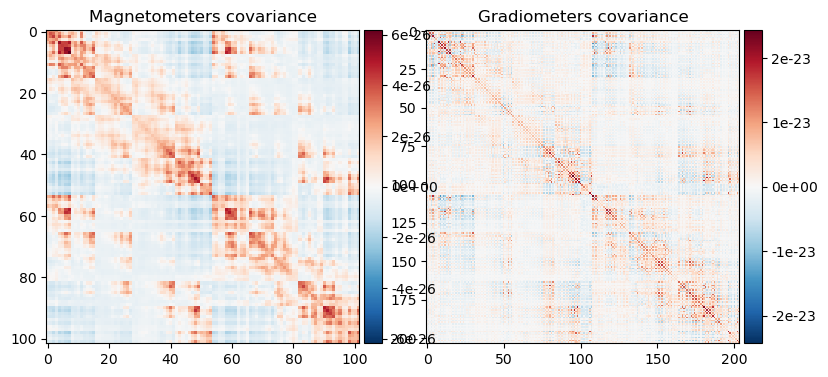

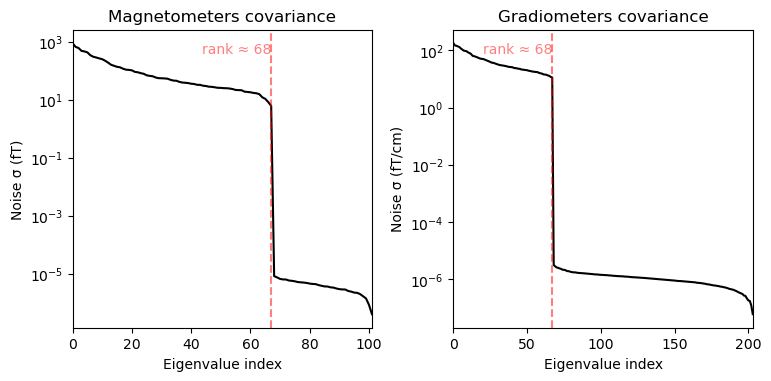

(<Figure size 760x370 with 4 Axes>, <Figure size 760x370 with 2 Axes>)

In [69]:
mne.viz.plot_cov(noise_cov, info=epochs.info)

We can visualize the whitening of the evoked data, using this noise covariance matrix:

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 2.6e-13 (2.2e-16 eps * 306 dim * 3.9  max singular value)
    Estimated rank (mag + grad): 68
    MEG: rank 68 computed from 306 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.6e-13 (2.2e-16 eps * 306 dim * 3.9  max singular value)
    Estimated rank (mag + grad): 68
    MEG: rank 68 computed from 306 data channels with 0 projectors
SSS has been applied to data. Showing mag and grad whitening jointly.
Computing rank from covariance with rank={'meg': 68}
    Setting small MEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 68 (238 small eigenvalues omitted)


/tmp/ipykernel_2780122/2760183956.py:2: RuntimeWarning: (X, Y) fit (3.3, 36.9) more than 20 mm from head frame origin
  evoked_contrast.plot_white(noise_cov, sphere=sphere);


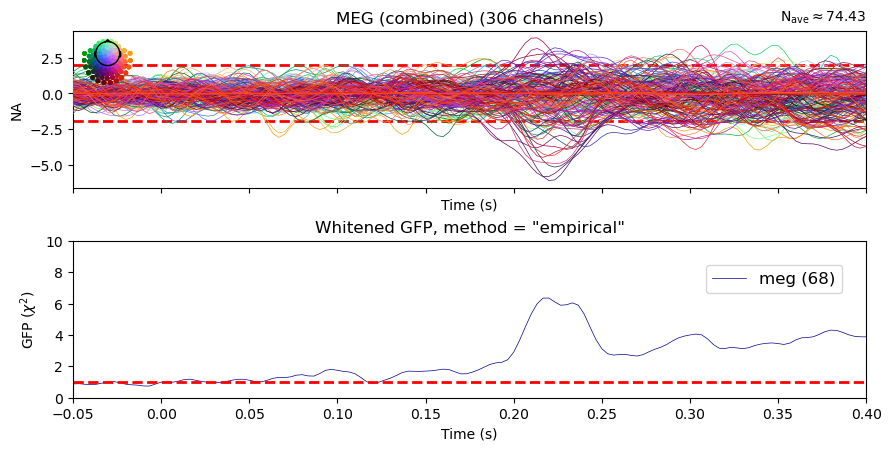

In [70]:
%matplotlib inline
evoked_contrast.plot_white(noise_cov, sphere=sphere);

Lastly, to perform source estimation, we also need to read the forward model that we had saved!

In [71]:
fwd_fname = os.path.join(extra_path,
    'source_recon/sub-01/sub-01-meg-fwd.fif')
fwd = mne.read_forward_solution(fwd_fname)

# Restrict forward solution to MEG channels only
fwd = mne.pick_types_forward(fwd, meg=True, eeg=False)

Reading forward solution from /home/vanvlm1/projects/mne_practical_meeg_2025/extra_data_mne/source_recon/sub-01/sub-01-meg-fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (8193 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    306 out of 306 channels remain after picking


## Compute MNE inverse operator and apply to evoked data

In [72]:
from mne.minimum_norm import make_inverse_operator, apply_inverse

Minimum norm inverse models are independant from the data (as they use just the noise covariance but not a data covariance matrix) and can therefore be precomputed and applied to the data at a later stage.

In [63]:
info = evoked_contrast.info
inverse_operator = make_inverse_operator(info, fwd, noise_cov, loose=0.2, depth=0.8)

Converting forward solution to surface orientation
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 306 channels.
    306 out of 306 channels remain after picking
Selected 306 channels
Creating the depth weighting matrix...
    204 planar channels
    limit = 7942/8193 = 10.094674
    scale = 2.09721e-08 exp = 0.8
Applying loose dipole orientations to surface source spaces: 0.2
Whitening the forward solution.
Computing rank from covariance with rank=None
    Using tolerance 2.6e-13 (2.2e-16 eps * 306 dim * 3.9  max singular value)
    Estimated rank (mag + grad): 68
    MEG: rank 68 computed from 306 data channels with 0 projectors
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead fiel

Now let's apply this inverse operator to our evoked contrast:

In [82]:
method = "dSPM"  # use the MNE-dSPM method
snr = 3.
lambda2 = 1. / snr ** 2  # regularization

stc_face = apply_inverse(evoked_face, inverse_operator, lambda2, method=method)
stc_scrambled = apply_inverse(evoked_scrambled, inverse_operator, lambda2, method=method)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 49
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 68 (238 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "0.27 × face/famous/first + 0.06 × face/famous/immediate + 0.12 × face/famous/long + 0.35 × face/unfamiliar/first + 0.08 × face/unfamiliar/immediate + 0.12 × face/unfamiliar/long"...
    Picked 306 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  91.5% variance
    Combining the current components...
    dSPM...
[done]
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 30
    Created the regularized inverter
    The projection vectors do not apply to these channels.
  

Let us plot one of the course estimates. You can explore the source reconstruction, e.g. by watching the activation as a movie.  
(keep the resulting window open for the next cell to work!)

In [77]:
brain_face = stc_face.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both")

Using control points [ 7.56398165  8.31465565 13.11064617]


When we have multiple brain plots open, we can link them together. In this manner we can compare between experimental contrasts.

In [78]:
brain_scrambled = stc_scrambled.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both")
mne.viz.link_brains([brain_face, brain_scrambled])  # link the brain plots

Using control points [ 5.68070672  6.32562694 11.12451343]
Using control points [3.68326044 4.03940084 6.13561805]


Of course, the most informative plot may be the contrast between conditions.
`SourceEstimate` objects support basic math operations such as addition and subtraction.

In [85]:
stc_contrast = stc_face - stc_scrambled
stc_contrast.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both")

Using control points [4.69490358 5.2999458  9.50398463]


<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>What do the negative and positive activations mean in the contrast plot?</li>
      <li>Can you save a screenshot of the activity at 220 ms?</li>
    </ul>
</div>

## About source orientations

Unlike fMRI data, MEG source estimates inherently have a direction as well as magnitude for each source point. By default, MNE-Python discards the direction and only keeps the magnitude. However, it is educational and useful to explore different ways to handling the directions.

One of the options is to just keep the directions and have a `VectorSourceEstimate` object:

In [120]:
stc_vec = apply_inverse(evoked_face, inverse_operator, lambda2, method=method, pick_ori="vector")
stc_vec.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both", initial_time=0.166)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 49
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 68 (238 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "0.27 × face/famous/first + 0.06 × face/famous/immediate + 0.12 × face/famous/long + 0.35 × face/unfamiliar/first + 0.08 × face/unfamiliar/immediate + 0.12 × face/unfamiliar/long"...
    Picked 306 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  91.5% variance
    dSPM...
[done]
Using control points [ 7.56398165  8.31465565 13.11064617]


Since the main source of MEG activity, pyramidical neurons, tend to be aligned orthogonal to the cortical surface, a useful prior is to fix the source orientation to always be in this direction. The direction is approximated by the normal vector of the 3D mesh, hence this option is called `"normal"`:

In [125]:
stc_fixed = apply_inverse(evoked_face, inverse_operator, lambda2, method=method, pick_ori="normal")
stc_fixed.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both", initial_time=0.166)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 49
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 68 (238 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "0.27 × face/famous/first + 0.06 × face/famous/immediate + 0.12 × face/famous/long + 0.35 × face/unfamiliar/first + 0.08 × face/unfamiliar/immediate + 0.12 × face/unfamiliar/long"...
    Picked 306 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  91.5% variance
    dSPM...
[done]
Using control points [ 7.35666578  8.11363367 12.92366348]


<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>What do negative values mean in a source estimate where the orientation is always orthogonal to the cortex?</li>
      <li>Up to now, we have always plotted source estimates on an "inflated" brain. Plot the <code>stc_fixed</code> source estamite while specifying <code>surface="white"</code> to see the wrinkles in the cortex. Do you see the pattern of positive and negative values?</li>
    </ul>
</div>


## Morphing data to an average brain for group studies

Depending on your MNE-Python installation (how long you've been using it and for what), this might prompt a download of the *fsaverage* data. This might take a while.

In [ ]:
mne.datasets.fetch_fsaverage(subjects_dir=subjects_dir)

In [86]:
morph = mne.compute_source_morph(stc_face, subject_from="sub-01", subject_to="fsaverage",
                                 subjects_dir=subjects_dir)
stc_fsaverage = morph.apply(stc_face)

surface source space present ...
Computing morph matrix...
    Left-hemisphere map read.
    Right-hemisphere map read.
    7 smooth iterations done.
    7 smooth iterations done.
[done]
[done]


In [87]:
stc_fsaverage.plot(subject="fsaverage", subjects_dir=subjects_dir, hemi="both")

Using control points [ 7.07616018  7.75798233 12.28072547]


<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>Run sLORETA on the same data and compare source localizations. </li>
    </ul>
</div>


## Compute beamformer and apply to evoked data

For beamforming, we need a **data covariance matrix**.

Since we want to contrast conditions, we will compute a so-called **common spatial filter** - meaning we will use a covariance matrix that was computed on both conditions jointly. In our case, that is all data.

The data covariance changes over time, hence if we compute it over a too long stretch of data, it will become inaccurate. Since the main effects seem to happen in the first 250ms, let's restrict our data to that time window.

In [104]:
data_cov = mne.compute_covariance(epochs, tmin=0., tmax=0.25,
                                  method='empirical', rank='info')

    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 306 -> 68
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 6004
[done]


Now we can compute the beamformer. Since we have data from two types of sensors (magnetometers and gradiometers), we need to specify the noise covariance matrix as well. This is needed to take care of the different orders of magnitudes of the sensor types.

In [114]:
from mne.beamformer import make_lcmv, apply_lcmv
filters = make_lcmv(epochs.info, fwd, data_cov, reg=0.05, noise_cov=noise_cov)

Computing rank from covariance with rank='info'
    MEG: rank 68 after 0 projectors applied to 306 channels
Computing rank from covariance with rank='info'
    MEG: rank 68 after 0 projectors applied to 306 channels
Making LCMV beamformer with rank {'meg': 68}
Computing inverse operator with 306 channels.
    306 out of 306 channels remain after picking
Selected 306 channels
Whitening the forward solution.
Computing rank from covariance with rank={'meg': 68}
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 8193 sources
Filter computation complete


Much like the MNE inverse operator, we can now apply the beamfor filter to all of our conditions. Since we computed the data covariance across the 0-250ms window, let's restrict the evoked data to that window as well.

In [117]:
stc_face = apply_lcmv(evoked=evoked_face.copy().crop(0, 0.25), filters=filters)
stc_scrambled = apply_lcmv(evoked=evoked_scrambled.copy().crop(0, 0.25), filters=filters)
stc_contrast = stc_face - stc_scrambled

combining the current components...
combining the current components...


Plotting one of the source estimates:

In [118]:
stc_contrast.plot(subjects_dir=subjects_dir, subject="sub-01", hemi="both", initial_time=0.220)

Using control points [0.39660584 0.44428856 0.90226146]


<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>Try applying either the MNE inverse operator or the LCMV beamformer to the <code>evoked_contrast</code> object Compare the result with <code>stc_face - stc_scrambled</code>. What is different about the result and why?</li>
    </ul>
</div>